In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import sys 

sys.path.append("../")
from MRS_load_interp_mod import compute_theta_u_percent
from utilitaries_func import plot_theta_z_simpler

In [2]:
# make synthetic water content distribution 

ncells = 712

theta = np.zeros(ncells)

ncells_nonsim = 12
dz = 1 #cm

theta_r = 0.02
theta_s = 0.10

zmax_MRS = 5000 # cm

n_cells_nonsim_sapro = 2 # number of layers of the non-simulated zone which are within saprolite layer 
nlayers_bedrock = ncells_nonsim-n_cells_nonsim_sapro
n_theta_MRS_values_bedrock = 1

theta_s_bed = 0.02
theta_MRS_bedrock = 0.01

theta[:(ncells-ncells_nonsim)] = np.linspace(theta_r, theta_s, ncells-ncells_nonsim)
theta[(ncells-ncells_nonsim):(ncells-ncells_nonsim)+n_cells_nonsim_sapro] = theta_s * np.ones(n_cells_nonsim_sapro)
theta[(ncells-ncells_nonsim+n_cells_nonsim_sapro):] = theta_s_bed

depth = np.zeros(ncells) # depth array, each value corresponds to the bottom of the cell
depth[:(ncells-ncells_nonsim)] = np.linspace(dz, ncells-ncells_nonsim, ncells-ncells_nonsim)

dz_nonsim = ( zmax_MRS - (ncells-ncells_nonsim) ) / ncells_nonsim

for i in range(ncells_nonsim):
    depth[ncells-ncells_nonsim+i] = ncells-ncells_nonsim + (i+1) * dz_nonsim

depth_m = depth/100

layer_bound_idx = [0, ncells-ncells_nonsim+n_cells_nonsim_sapro]

theta_u_percent_base = [0.30]
theta_u_percent_max = [0.80]
S_lim = [0.45]

In [3]:
# compute theta_u_percent for layers above the bedrock only, 1 parameter for bedrock: theta_MRS,bed
eff_sat, theta_u_percent = compute_theta_u_percent(theta[:ncells-ncells_nonsim+n_cells_nonsim_sapro], [theta_s], [theta_r],
                                                    layer_bound_idx, theta_u_percent_base, S_lim, theta_u_percent_max)

In [4]:
theta_u_percent_fullarr = np.ones(theta.shape[0])
theta_u_percent_fullarr[:theta_u_percent.shape[0]] = theta_u_percent
theta_bedrock_fullarr = np.zeros(theta.shape[0])
theta_bedrock_fullarr[-nlayers_bedrock:] = theta_MRS_bedrock * np.ones(nlayers_bedrock)
theta_MRS = theta * (1-theta_u_percent_fullarr) + theta_bedrock_fullarr

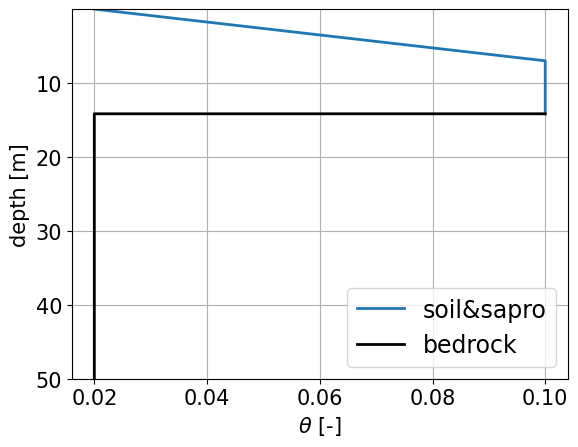

In [5]:
plt.figure()
plot_theta_z_simpler(depth_m, [theta[:(ncells-ncells_nonsim+n_cells_nonsim_sapro)]], [theta[(ncells-ncells_nonsim+n_cells_nonsim_sapro):]],
                      nlayers_bedrock, n_theta_MRS_values_bedrock, labels=['soil&sapro', 'bedrock'],
                      savefig = True)

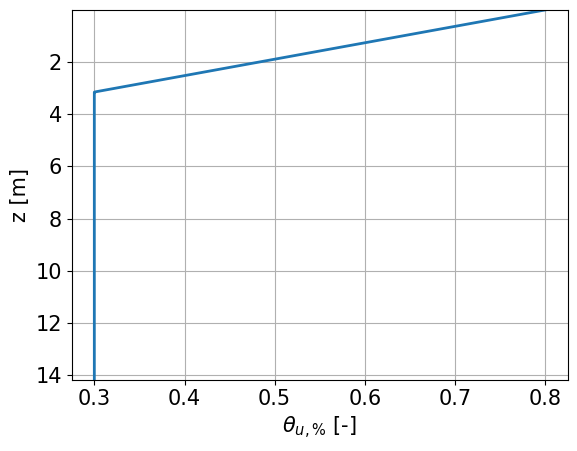

In [6]:
fs = 15
plt.figure()
plt.plot(theta_u_percent, depth_m[:ncells-ncells_nonsim+n_cells_nonsim_sapro], linewidth=2)
plt.ylim((max(depth_m[:ncells-ncells_nonsim+n_cells_nonsim_sapro]), min(depth_m[:ncells-ncells_nonsim+n_cells_nonsim_sapro])))
plt.ylabel('z [m]', fontsize = fs)
plt.xlabel(r'$\theta_{u,\%}$ [-]', fontsize = fs)
plt.yticks(fontsize = fs)
plt.xticks(fontsize = fs)
plt.grid()
plt.savefig('theta_u_percent_z.png', dpi=300, bbox_inches='tight')

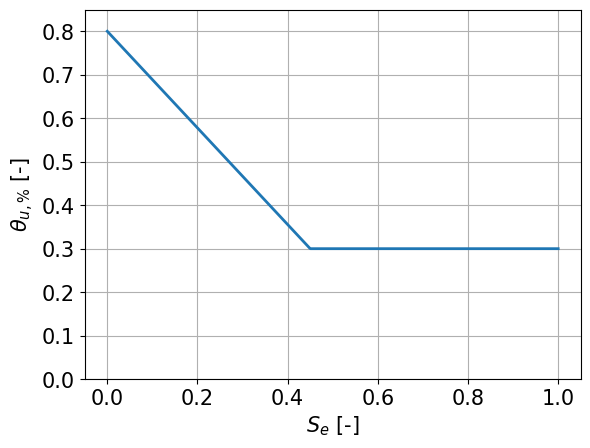

In [7]:
fs = 15
plt.figure()
plt.plot(eff_sat, theta_u_percent, linewidth=2)
plt.ylim(0, max(theta_u_percent)+0.05)
plt.ylabel(r'$\theta_{u,\%}$ [-]', fontsize = fs)
plt.xlabel(r'$S_e$ [-]', fontsize = fs)
plt.yticks(fontsize = fs)
plt.xticks(fontsize = fs)
plt.grid()
plt.savefig('theta_u_percent_Se_exple.png', dpi = 300, bbox_inches='tight')

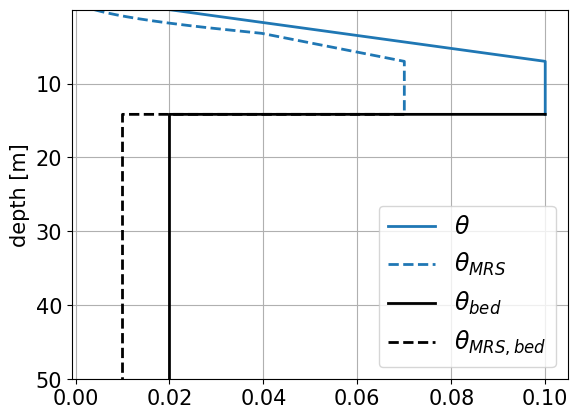

In [8]:
plt.figure()
plot_theta_z_simpler(depth_m, [theta[:(ncells-ncells_nonsim+n_cells_nonsim_sapro)], theta_MRS[:(ncells-ncells_nonsim+n_cells_nonsim_sapro)]], 
                              [theta[(ncells-ncells_nonsim+n_cells_nonsim_sapro):], theta_MRS[(ncells-ncells_nonsim+n_cells_nonsim_sapro):]],
                                nlayers_bedrock, n_theta_MRS_values_bedrock, labels=[r'$\theta$', r'$\theta_{MRS}$', r'$\theta_{bed}$', r'$\theta_{MRS,bed}$'], xlabel = '',
                                colors = ['C0', 'black'],
                                savefig=True, pngtitle = 'theta_theta_MRS_z.png')